# V1.5 — Regulator + bounded reserve → emergent mortality & envelope shape

**Targets:** Decisions **#19** (the regulator primitive; actuation spends a bounded conserved reserve) and **#21** (the viability margin as the living-asset currency); ARCHITECTURE §III.6. **Depends on:** — (none). **Gates:** living-asset work (architecture Phase 2), together with V1.6 (protocol §9).

**Claim (one falsifiable sentence).** A minimal regulated subsystem (a cardiovascular loop + a finite reserve) **recovers from small perturbations** and, past a **reserve-dependent threshold**, ignites a **positive-feedback cascade to an absorbing death state** — with the **viable region shrinking as the reserve depletes**.

**Load-bearing because.** This is the architecture's whole theory of life: mortality must be *emergent from a conserved quantity running out*, not a scripted hit-point counter, and the **viability margin** (distance to the envelope boundary) must play the exact role the homogenization bound plays for passive matter (ARCHITECTURE Part IV — the single currency). If the envelope is not real and reserve-dependent, the living-asset machinery has no meaning.

**Nature.** Empirical (dynamical-systems characterization). **Failure → outcome:** REDESIGN the regulator/reserve coupling.

### The minimal model (2-D fast loop, reserve `r` as the swept parameter)
State `(P, x)`: `P` = mean perfusion pressure (the sensed variable), `x` = autonomic/pump tone (the actuator). Reserve `r ∈ (0, r0]` sets the actuator capacity `a_max(r)=a_cap·r/r0`.
$$\dot P = \mathrm{pump}(P)\,(1+\beta x) - \gamma P,\qquad \mathrm{pump}(P)=\frac{P_{\max}P^n}{P^n+P_c^n},\qquad \dot x = \tfrac1\tau\big[\,\mathrm{clip}(K(P_{set}-P),\,0,\,a_{\max}(r)) - x\,\big].$$
`pump(0)=0` ⇒ **`P=0` is an exact absorbing collapse** (low P → weak pump → lower P: the hemorrhagic spiral). `γ` is set so the **bare pump has no upper equilibrium** — the healthy state exists *only* because the reserve-fed regulator boosts the pump. So a healthy stable node and the absorbing collapse are separated by a **saddle**, whose stable manifold is the **separatrix** (= envelope boundary). As `r↓`, `a_max↓`, the controller **saturates**, and the healthy node and the saddle annihilate at a **saddle-node bifurcation `r_crit`** — past which only death exists. A coupled slow reserve `ṙ = −c·max(x−x_base,0)+s·(r0−r)` gives the death-from-bleeding demonstration.

### Oracle — cheap viability margin vs the brute-force basin (protocol §V1.5)
The *shippable* object is the cheap **viability-margin** scalar (signed distance to the separatrix: >0 alive, <0 dead). The independent **ground truth**, obtained a different way, is the **brute-force basin of attraction**: integrate the ODE from a dense grid of initial states and label each by its attractor. V1.5 passes iff the cheap predicate agrees with the true basin, the basin contracts monotonically with reserve, and collapse is absorbing. (All implemented in `oracles/regulator.py`.)

### Pre-registered pass criteria (frozen *before* running; calibrated with margin)
| # | Metric | Threshold | Failure → outcome |
|---|--------|-----------|-------------------|
| **A** | healthy FP at full reserve | a healthy fixed point exists with Jacobian eigenvalues all `Re<0`; a **saddle** separates it from an **absorbing** collapse (P=0 stable) | REDESIGN regulator/reserve coupling |
| **B** | basin vs reserve | the basin measure (**critical bleed**) is **monotone non-increasing** as `r↓` (within ε) and **→ 0 at a finite `r_crit`** where the healthy FP disappears (saddle-node), `0.05 < r_crit < 0.5` | REDESIGN |
| **C** | currency + absorbing | the cheap viability-margin sign agrees with the true brute-force basin for **≥ 99%** of a state grid; **0** trajectories that start dead recover (no spurious recovery); collapse is an attractor | REDESIGN |
| **D** | positive-feedback (support) | the saddle has a positive eigenvalue and the collapse region is autocatalytic (`∂Ṗ/∂P > 0`) — a regenerative cascade, not a drain (diagnostic, not a gate) | diagnostic only |

**Expected verdict: PASS** — homeostasis that recovers small perturbations, a reserve-dependent viable envelope that contracts to a saddle-node where life becomes impossible, an absorbing positive-feedback death cascade, and a cheap viability-margin predicate that matches the exact basin.

In [1]:
"""(1) Setup — imports, frozen pre-registered constants, the regulator model."""
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles" / "regulator.py").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))
RESULTS = REPO / "verification_notebooks" / "phase1" / "results"

import regulator as rg

np.set_printoptions(precision=3, suppress=True)
p = rg.RegulatorParams()                         # the frozen, calibrated physiological constants

# ---- PRE-REGISTERED constants (frozen after calibration) ----
RESERVE_SWEEP = [1.0, 0.8, 0.6, 0.4, 0.3, 0.25]  # B: reserve levels for basin contraction
AGREE_MIN     = 0.99                              # C: viability-margin vs true-basin agreement
RCRIT_RANGE   = (0.05, 0.5)                       # B: the saddle-node must sit in a finite window
MONO_EPS      = 1e-3                              # B: monotonicity slack on critical-bleed
P_GRID = np.linspace(0.0, 2.4, 30)               # C: brute-force basin state grid
X_GRID = np.linspace(0.0, p.a_cap, 20)
BLEED_SURVIVE, BLEED_FATAL = 0.02, 0.05          # D: hemorrhage drain rates (survivable / fatal)
BLEED_WINDOW = (20.0, 60.0)

print(f"params: P_set={p.P_set} gamma={p.gamma} beta={p.beta} K={p.K} a_cap={p.a_cap} tau={p.tau}")
# bare pump has no upper FP (the healthy state requires regulation) — the model's premise
Ps = np.linspace(0.05, 3.0, 4000); bare = rg.pump(Ps, p) - p.gamma * Ps
BARE_NO_UPPER = not np.any(bare[:-1] * bare[1:] < 0)
print(f"bare-pump upper equilibrium exists: {not BARE_NO_UPPER}  (premise: False — life needs the regulator)")

params: P_set=1.4 gamma=1.4 beta=2.0 K=2.0 a_cap=1.0 tau=0.1
bare-pump upper equilibrium exists: False  (premise: False — life needs the regulator)


## (A) Fixed points & stability at full reserve

List every equilibrium of the fast loop at `r = r0` with its Jacobian eigenvalues: a healthy stable node (active negative feedback, with headroom), a saddle (one positive eigenvalue ⇒ the cascade), and the **absorbing** collapse `P=0`.

In [2]:
"""(2) A: fixed points + stability at full reserve; absorbing collapse."""
fps = rg.fixed_points(p, p.r0)
print("(A) full-reserve fixed points")
for fp in fps:
    print(f"   P={fp['P']:.3f}  x={fp['x']:.3f}  {fp['kind']:11s}  eig.Re={fp['eig'].real}")

healthy = rg.healthy_fp(p, p.r0)
saddle  = rg.saddle_fp(p, p.r0)
collapse = fps[0]                                  # (P=0, x=a_max) — by construction the first

# collapse is an attractor (absorbing): perturb off it and it returns
sol = solve_ivp(lambda t, s: rg.rhs(s, p, p.r0), [0, 100], [0.05, collapse["x"]],
                rtol=1e-7, atol=1e-9, method="LSODA")
collapse_absorbing = sol.y[0, -1] < 1e-3

A_PASS = (healthy is not None and all(healthy["eig"].real < -1e-9)
          and saddle is not None and saddle["eig"].real.max() > 1e-9
          and collapse["P"] == 0.0 and collapse["kind"] == "stable_node" and collapse_absorbing
          and BARE_NO_UPPER)
print(f"\n   healthy node: P={healthy['P']:.3f} stable={all(healthy['eig'].real<0)} "
      f"saturated={rg.saturated(healthy['P'], p.r0, p)} (active control with headroom)")
print(f"   saddle: P={saddle['P']:.3f}  positive eigenvalue={saddle['eig'].real.max():.3f}")
print(f"   collapse P=0 absorbing: {collapse_absorbing}")
print(f"   -> A_PASS = {A_PASS}")

(A) full-reserve fixed points
   P=0.000  x=1.000  stable_node  eig.Re=[ -1.4 -10. ]
   P=0.422  x=1.000  saddle       eig.Re=[  3.096 -10.   ]
   P=1.203  x=0.394  stable_node  eig.Re=[-5.537 -5.537]

   healthy node: P=1.203 stable=True saturated=False (active control with headroom)
   saddle: P=0.422  positive eigenvalue=3.096
   collapse P=0 absorbing: True
   -> A_PASS = True


## (B) Reserve sweep → monotone basin contraction to a saddle-node

As the reserve depletes the actuator capacity falls; measure the **critical bleed** (the largest instantaneous pressure drop from the healthy node that still recovers — the basin-boundary location, obtained by integration) at each reserve level. It must contract monotonically to **0** at a finite `r_crit` where the healthy fixed point ceases to exist (the saddle-node).

In [3]:
"""(3) B: critical-bleed vs reserve (monotone -> 0) and the saddle-node r_crit."""
crit_bleed = [rg.critical_bleed(p, r) for r in RESERVE_SWEEP]
r_crit = rg.r_critical(p)

monotone = all(crit_bleed[i] >= crit_bleed[i + 1] - MONO_EPS for i in range(len(crit_bleed) - 1))
healthy_above = rg.healthy_fp(p, r_crit * 1.05) is not None     # alive just above r_crit
dead_below    = rg.healthy_fp(p, r_crit * 0.90) is None         # dead just below r_crit
rcrit_ok = RCRIT_RANGE[0] < r_crit < RCRIT_RANGE[1]

B_PASS = monotone and healthy_above and dead_below and rcrit_ok
print("(B) basin contraction with reserve")
print("   reserve    :", RESERVE_SWEEP)
print("   crit-bleed :", list(np.round(crit_bleed, 3)))
print(f"   monotone non-increasing: {monotone}")
print(f"   saddle-node r_crit = {r_crit:.3f}  (healthy exists above: {healthy_above}, gone below: {dead_below})")
print(f"   -> B_PASS = {B_PASS}")

(B) basin contraction with reserve
   reserve    : [1.0, 0.8, 0.6, 0.4, 0.3, 0.25]
   crit-bleed : [np.float64(0.761), np.float64(0.735), np.float64(0.699), np.float64(0.638), np.float64(0.387), np.float64(0.172)]
   monotone non-increasing: True
   saddle-node r_crit = 0.237  (healthy exists above: True, gone below: True)
   -> B_PASS = True


## (C) Viability margin vs the true basin (the currency check)

Build the cheap **viability-margin** predicate (one backward integration for the separatrix, then a table lookup) and compare its sign against the **brute-force basin** (full ODE integration from every grid state). Agreement must be ≥ 99%, with **no spurious recovery** — no state the predicate calls dead actually recovers.

In [4]:
"""(4) C: cheap viability margin vs brute-force basin; no spurious recovery."""
mask_true, Ph = rg.basin_map(p, p.r0, P_GRID, X_GRID)            # THE ORACLE (integrated attractor)
margin_fn, sep = rg.make_viability_margin(p, p.r0)
pred_alive = np.array([[margin_fn(P0, x0) > 0 for P0 in P_GRID] for x0 in X_GRID])

agreement = float((pred_alive == mask_true).mean())
# spurious recovery: a state the cheap margin calls DEAD that truly converges to the healthy node
spurious_recovery = int(np.sum((~pred_alive) & mask_true))

C_PASS = agreement >= AGREE_MIN and spurious_recovery == 0 and collapse_absorbing
print("(C) viability margin vs true basin")
print(f"   agreement = {agreement:.3f} over {mask_true.size} states  (need >= {AGREE_MIN})")
print(f"   spurious recoveries (margin<0 but recovers) = {spurious_recovery}  (need 0)")
print(f"   collapse absorbing = {collapse_absorbing}")
print(f"   -> C_PASS = {C_PASS}")

(C) viability margin vs true basin
   agreement = 1.000 over 600 states  (need >= 0.99)
   spurious recoveries (margin<0 but recovers) = 0  (need 0)
   collapse absorbing = True
   -> C_PASS = True


## (D, supporting) Positive-feedback cascade & the coupled death-from-bleeding demo

Confirm the collapse is a **regenerative** cascade (the saddle has a positive eigenvalue; the loop gain `∂Ṗ/∂P > 0` below the saddle — autocatalytic), then run the coupled slow-reserve system: a survivable vs a fatal hemorrhage. The fatal bleed drains the reserve below `r_crit`, the healthy node vanishes, and `P` collapses — **death because the conserved reserve ran out**, not a scripted event.

In [5]:
"""(5) D: positive-feedback diagnostic + coupled bleed -> recovery vs death."""
# loop gain dPdot/dP at fixed tone, just below the saddle (the autocatalytic region)
def dPdot_dP(P, x, eps=1e-5):
    f = lambda PP: rg.pump(PP, p) * (1 + p.beta * x) - p.gamma * PP
    return (f(P + eps) - f(P - eps)) / (2 * eps)
loop_gain = max(dPdot_dP(P, saddle["x"]) for P in np.linspace(0.05, saddle["P"] * 0.95, 8))
pos_feedback = saddle["eig"].real.max() > 0 and loop_gain > 0

# coupled (P,x,r) bleed runs from the 3-D resting equilibrium
rest = solve_ivp(lambda t, s: rg.rhs_full(s, p), [0, 2000], [healthy["P"], healthy["x"], 1.0],
                 rtol=1e-9, atol=1e-11, method="LSODA").y[:, -1]

def run_bleed(sink, tmax=300):
    def f(t, s):
        d = rg.rhs_full(s, p).copy()
        if BLEED_WINDOW[0] <= t <= BLEED_WINDOW[1]:
            d[2] -= sink                                          # hemorrhage: extra reserve drain
        return d
    return solve_ivp(f, [0, tmax], rest, rtol=1e-8, atol=1e-10, method="LSODA",
                     max_step=0.5, t_eval=np.linspace(0, tmax, 1600))

sol_live = run_bleed(BLEED_SURVIVE); sol_die = run_bleed(BLEED_FATAL)
survived = sol_live.y[0, -1] > 0.5 * healthy["P"] and sol_live.y[2].min() > r_crit
died     = sol_die.y[0, -1] < 0.1 and sol_die.y[2].min() < r_crit
D_PASS = pos_feedback and survived and died                      # supporting (always reported)
print("(D) positive-feedback cascade + coupled mortality")
print(f"   saddle positive eigenvalue = {saddle['eig'].real.max():.3f}; loop gain below saddle = {loop_gain:.3f} (>0)")
print(f"   3-D resting equilibrium: P*={rest[0]:.3f} x*={rest[1]:.3f} r*={rest[2]:.3f} (> r_crit={r_crit:.3f})")
print(f"   survivable bleed (sink={BLEED_SURVIVE}): r_min={sol_live.y[2].min():.3f} end P={sol_live.y[0,-1]:.3f} -> {'recovered' if survived else 'died'}")
print(f"   fatal bleed     (sink={BLEED_FATAL}): r_min={sol_die.y[2].min():.3f} end P={sol_die.y[0,-1]:.3f} -> {'DEAD' if died else 'survived'}")
print(f"   -> D_PASS = {D_PASS}")

(D) positive-feedback cascade + coupled mortality
   saddle positive eigenvalue = 3.096; loop gain below saddle = 2.753 (>0)
   3-D resting equilibrium: P*=1.203 x*=0.394 r*=0.418 (> r_crit=0.237)
   survivable bleed (sink=0.02): r_min=0.300 end P=1.203 -> recovered
   fatal bleed     (sink=0.05): r_min=0.041 end P=0.000 -> DEAD
   -> D_PASS = True


## Figure

saved /workspace/nebula/verification_notebooks/phase1/results/V1_5_regulator_mortality.png


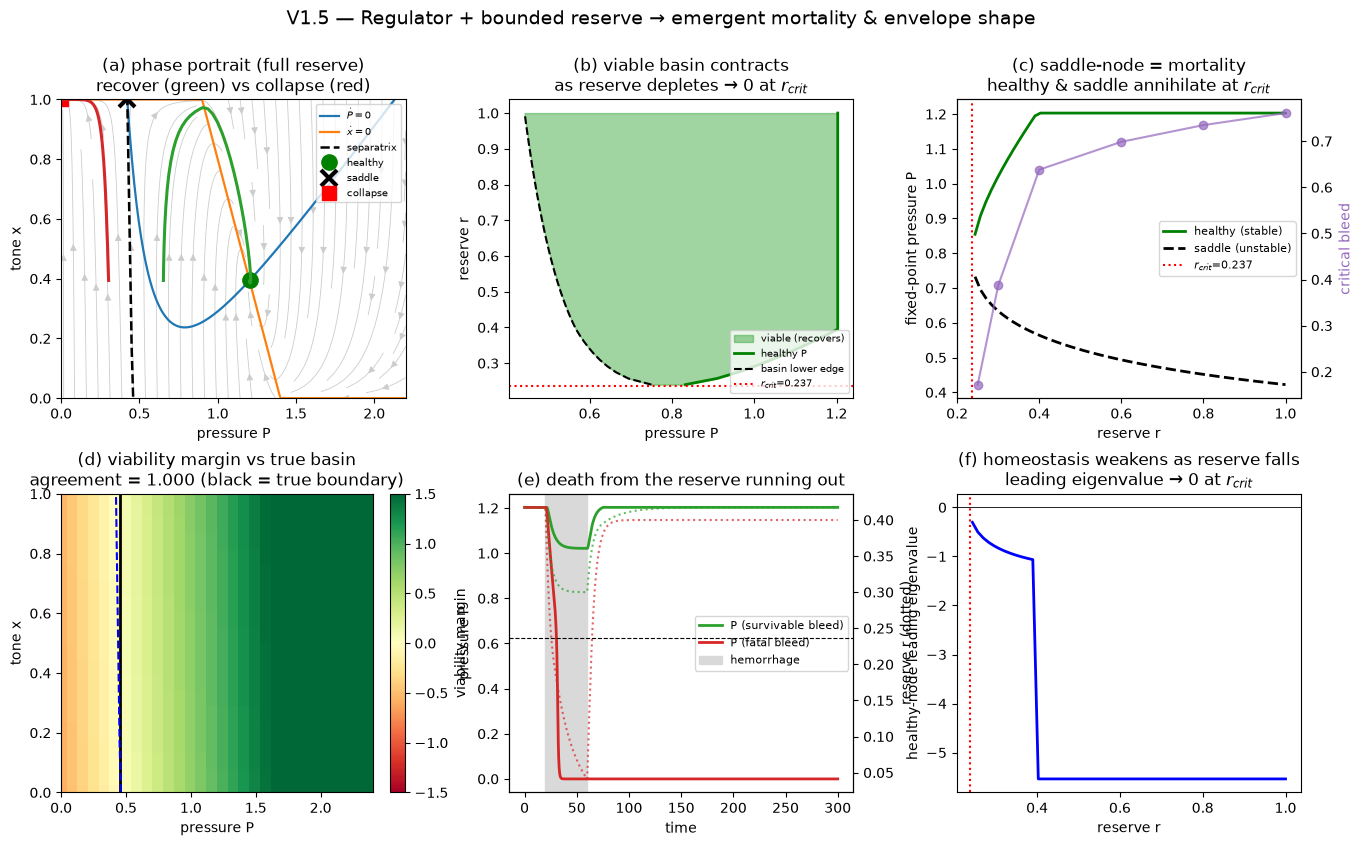

In [6]:
"""(6) Figure: phase portrait, contracting basins, saddle-node, margin-vs-basin, death cascade."""
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 3, hspace=0.32, wspace=0.30)

def vfield(P, x, r):
    dP = rg.pump(P, p) * (1 + p.beta * x) - p.gamma * P
    at = np.clip(p.K * (p.P_set - P), 0.0, rg.a_max(r, p))
    return dP, (at - x) / p.tau

# (a) phase portrait at full reserve: streamlines, nullclines, FPs, separatrix, two trajectories
ax = fig.add_subplot(gs[0, 0])
Pm, Xm = np.meshgrid(np.linspace(0.01, 2.2, 28), np.linspace(0.0, p.a_cap, 24))
dP, dX = vfield(Pm, Xm, p.r0)
ax.streamplot(Pm, Xm, dP, dX, color="0.8", density=1.0, linewidth=0.6)
Pl = np.linspace(0.05, 2.2, 300)
ax.plot(Pl, (p.gamma * Pl / rg.pump(Pl, p) - 1) / p.beta, "tab:blue", lw=1.6, label="$\\dot P=0$")
ax.plot(Pl, np.clip(p.K * (p.P_set - Pl), 0, rg.a_max(p.r0, p)), "tab:orange", lw=1.6, label="$\\dot x=0$")
if sep is not None:
    ax.plot(sep[:, 0], sep[:, 1], "k--", lw=1.8, label="separatrix")
ax.plot([healthy["P"]], [healthy["x"]], "go", ms=11, label="healthy")
ax.plot([saddle["P"]], [saddle["x"]], "kx", ms=11, mew=3, label="saddle")
ax.plot([collapse["P"]], [collapse["x"]], "rs", ms=10, label="collapse")
for P0, col in [(healthy["P"] - 0.55, "tab:green"), (healthy["P"] - 0.9, "tab:red")]:
    s = solve_ivp(lambda t, st: rg.rhs(st, p, p.r0), [0, 30], [P0, healthy["x"]],
                  rtol=1e-7, atol=1e-9, max_step=0.05)
    ax.plot(s.y[0], s.y[1], col, lw=2.2)
ax.set_xlim(0, 2.2); ax.set_ylim(0, p.a_cap); ax.set_xlabel("pressure P"); ax.set_ylabel("tone x")
ax.set_title("(a) phase portrait (full reserve)\nrecover (green) vs collapse (red)"); ax.legend(fontsize=7, loc="upper right")

# (b) survivable-pressure funnel: the viable P-band narrows to a point at r_crit (basin contracts)
ax = fig.add_subplot(gs[0, 1])
rr_b = np.linspace(r_crit + 0.003, 1.0, 45)
Ph_b = np.array([rg.healthy_fp(p, r)["P"] for r in rr_b])
cb_b = np.array([rg.critical_bleed(p, r) for r in rr_b])
ax.fill_betweenx(rr_b, Ph_b - cb_b, Ph_b, color="tab:green", alpha=0.45, label="viable (recovers)")
ax.plot(Ph_b, rr_b, "g-", lw=2, label="healthy P")
ax.plot(Ph_b - cb_b, rr_b, "k--", lw=1.5, label="basin lower edge")
ax.axhline(r_crit, color="r", ls=":", lw=1.5, label=f"$r_{{crit}}$={r_crit:.3f}")
ax.set_xlabel("pressure P"); ax.set_ylabel("reserve r")
ax.set_title("(b) viable basin contracts\nas reserve depletes → 0 at $r_{crit}$"); ax.legend(fontsize=7, loc="lower right")

# (c) saddle-node bifurcation diagram + critical bleed
ax = fig.add_subplot(gs[0, 2])
rr = np.linspace(max(r_crit - 0.02, 0.01), 1.0, 60)
Hh = [rg.healthy_fp(p, r) for r in rr]; Ss = [rg.saddle_fp(p, r) for r in rr]
ax.plot([r for r, h in zip(rr, Hh) if h], [h["P"] for h in Hh if h], "g-", lw=2, label="healthy (stable)")
ax.plot([r for r, s in zip(rr, Ss) if s], [s["P"] for s in Ss if s], "k--", lw=2, label="saddle (unstable)")
ax.axvline(r_crit, color="r", ls=":", label=f"$r_{{crit}}$={r_crit:.3f}")
ax.set_xlabel("reserve r"); ax.set_ylabel("fixed-point pressure P")
ax.set_title("(c) saddle-node = mortality\nhealthy & saddle annihilate at $r_{crit}$"); ax.legend(fontsize=8)
axt = ax.twinx(); axt.plot(RESERVE_SWEEP, crit_bleed, "o-", color="tab:purple", alpha=0.7)
axt.set_ylabel("critical bleed", color="tab:purple")

# (d) viability-margin sign field vs true basin boundary
ax = fig.add_subplot(gs[1, 0])
MP, MX = np.meshgrid(P_GRID, X_GRID)
marg = np.array([[margin_fn(P0, x0) for P0 in P_GRID] for x0 in X_GRID])
im = ax.pcolormesh(MP, MX, marg, cmap="RdYlGn", vmin=-1.5, vmax=1.5, shading="auto")
ax.contour(MP, MX, mask_true.astype(float), levels=[0.5], colors="k", linewidths=2)
if sep is not None:
    ax.plot(sep[:, 0], sep[:, 1], "b--", lw=1.5)
ax.set_xlim(P_GRID.min(), P_GRID.max()); ax.set_ylim(X_GRID.min(), X_GRID.max())
ax.set_xlabel("pressure P"); ax.set_ylabel("tone x")
ax.set_title(f"(d) viability margin vs true basin\nagreement = {agreement:.3f} (black = true boundary)")
fig.colorbar(im, ax=ax, fraction=0.046, label="viability margin")

# (e) coupled death cascade: P(t) and r(t), survivable vs fatal bleed
ax = fig.add_subplot(gs[1, 1])
ax.plot(sol_live.t, sol_live.y[0], "tab:green", lw=2, label="P (survivable bleed)")
ax.plot(sol_die.t, sol_die.y[0], "tab:red", lw=2, label="P (fatal bleed)")
ax.axvspan(*BLEED_WINDOW, color="0.85", label="hemorrhage")
ax.set_xlabel("time"); ax.set_ylabel("pressure P"); ax.set_title("(e) death from the reserve running out")
ax.legend(fontsize=8, loc="center right")
axr = ax.twinx()
axr.plot(sol_live.t, sol_live.y[2], "tab:green", ls=":", alpha=0.7)
axr.plot(sol_die.t, sol_die.y[2], "tab:red", ls=":", alpha=0.7)
axr.axhline(r_crit, color="k", ls="--", lw=0.8); axr.set_ylabel("reserve r (dotted)")

# (f) stability loss: healthy-node leading eigenvalue -> 0 at r_crit
ax = fig.add_subplot(gs[1, 2])
lead = [(r, max(rg.healthy_fp(p, r)["eig"].real)) for r in rr if rg.healthy_fp(p, r)]
ax.plot([r for r, e in lead], [e for r, e in lead], "b-", lw=2)
ax.axvline(r_crit, color="r", ls=":"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("reserve r"); ax.set_ylabel("healthy-node leading eigenvalue")
ax.set_title("(f) homeostasis weakens as reserve falls\nleading eigenvalue → 0 at $r_{crit}$")

fig.suptitle("V1.5 — Regulator + bounded reserve → emergent mortality & envelope shape", fontsize=14, y=0.98)
OUT = RESULTS / "V1_5_regulator_mortality.png"
fig.savefig(OUT, dpi=110, bbox_inches="tight")
print(f"saved {OUT}")
plt.show()

In [7]:
"""(7) Frozen verdict."""
def verdict(name, passed, detail, outcome):
    print(f"  [{'OK ' if passed else 'XX '}] {name:32s} {'PASS' if passed else f'FAIL -> {outcome}'}")
    print(f"        {detail}")

print("=" * 84)
print("V1.5 — REGULATOR + BOUNDED RESERVE -> EMERGENT MORTALITY & ENVELOPE SHAPE — VERDICT")
print("=" * 84)
verdict("A. healthy FP & absorbing collapse", A_PASS,
        f"healthy node P={healthy['P']:.3f} stable (eig.Re<0); saddle P={saddle['P']:.3f}; "
        f"collapse P=0 absorbing; bare pump has no healthy FP", "REDESIGN coupling")
verdict("B. basin contracts to saddle-node", B_PASS,
        f"critical-bleed monotone {np.round(crit_bleed,2)} -> 0 at r_crit={r_crit:.3f} "
        f"(healthy FP vanishes below)", "REDESIGN")
verdict("C. viability margin = true basin", C_PASS,
        f"cheap margin agrees with brute-force basin {agreement:.1%} of {mask_true.size} states; "
        f"{spurious_recovery} spurious recoveries", "REDESIGN")
verdict("D. positive-feedback mortality", D_PASS,
        f"saddle eig+={saddle['eig'].real.max():.2f}, loop gain={loop_gain:.2f}>0; fatal bleed drains "
        f"r<r_crit -> death, survivable bleed recovers", "diagnostic")

ALL_PASS = A_PASS and B_PASS and C_PASS and D_PASS
print("=" * 84)
if ALL_PASS:
    print("  V1.5 OVERALL: PASS — a regulated homeostatic fixed point recovers small perturbations; the")
    print("                viable envelope contracts monotonically as the bounded reserve depletes, to a")
    print("                saddle-node where life becomes impossible; death is an absorbing positive-")
    print("                feedback cascade triggered by the reserve running out; and the cheap viability")
    print("                margin matches the exact basin (the living-asset currency is real).")
    print("  -> Only V1.6 (regulator numerical stability) remains before architecture Phase 2.")
else:
    print("  V1.5 OVERALL: FAIL — see outcome class above.")
print("=" * 84)
assert ALL_PASS, "V1.5 did not pass — see verdict above."

V1.5 — REGULATOR + BOUNDED RESERVE -> EMERGENT MORTALITY & ENVELOPE SHAPE — VERDICT
  [OK ] A. healthy FP & absorbing collapse PASS
        healthy node P=1.203 stable (eig.Re<0); saddle P=0.422; collapse P=0 absorbing; bare pump has no healthy FP
  [OK ] B. basin contracts to saddle-node PASS
        critical-bleed monotone [0.76 0.73 0.7  0.64 0.39 0.17] -> 0 at r_crit=0.237 (healthy FP vanishes below)
  [OK ] C. viability margin = true basin PASS
        cheap margin agrees with brute-force basin 100.0% of 600 states; 0 spurious recoveries
  [OK ] D. positive-feedback mortality   PASS
        saddle eig+=3.10, loop gain=2.75>0; fatal bleed drains r<r_crit -> death, survivable bleed recovers
  V1.5 OVERALL: PASS — a regulated homeostatic fixed point recovers small perturbations; the
                viable envelope contracts monotonically as the bounded reserve depletes, to a
                saddle-node where life becomes impossible; death is an absorbing positive-
                fee